In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import os
import sys
sys.path.insert(0, '..')
from titan.Experiment import Experiment
from titan.plt_Experiment_summary import titan_plt_summary, titan_plt_summary_temp
from titan.load_and_preprocessing import titan_load_and_preprocessing
import sigmoid_fitting as sp
from titan.processing_DNA import titan_plt_infl

import pickle

# Data Loading

In [2]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/"
exp_path = Path(exp_folder, "5Plex_dLAMP_oldData.csv")

name_conv = {
    "ia": "IAV",
    "ib": "IBV",
    "c19": "SARS-CoV-2",
    "ad": "hAdV",
    "kp": "KP",
}

dlamp_data = pd.read_csv(exp_path)
dlamp_data = dlamp_data.replace({"Target": name_conv})
dlamp_data.head()

,Unnamed: 0,Channel,PrimerMix,Target,Assay,Conc,Exp_id,MeltPeaks,1.0,2.0,...,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0
0,163,panel31,5plex_A,hAdV,RM5,10000,20201202_01,89.891032,0.002267,-0.000116,...,0.857027,0.860285,0.861350,0.862313,0.865087,0.868469,0.868767,0.866020,0.863320,0.859830
1,758,panel31,5plex_A,hAdV,RM5,10000,20201202_01,89.988709,0.000256,-0.000021,...,0.769405,0.789562,0.806199,0.819269,0.830892,0.840751,0.848472,0.852250,0.855393,0.857357
2,773,panel32,5plex_A,hAdV,RM5,10000,20201202_01,89.922761,0.011026,-0.000079,...,0.865367,0.870166,0.874423,0.879303,0.883929,0.891143,0.898757,0.903821,0.907025,0.909138
3,883,panel32,5plex_A,hAdV,RM5,10000,20201202_01,90.251498,0.010897,-0.000136,...,0.821305,0.824715,0.828080,0.829484,0.827414,0.825484,0.826902,0.831704,0.833142,0.831284
4,1273,panel32,5plex_A,hAdV,RM5,10000,20201202_01,90.061983,0.010105,-0.000113,...,0.891640,0.897069,0.904282,0.910942,0.919224,0.924997,0.927717,0.928439,0.929521,0.930995


In [3]:
print(dlamp_data.shape)
print(dlamp_data.dtypes)

(54186, 43)
Unnamed: 0      int64
Channel        object
PrimerMix      object
Target         object
Assay          object
Conc            int64
Exp_id         object
MeltPeaks     float64
1.0           float64
2.0           float64
3.0           float64
4.0           float64
5.0           float64
6.0           float64
7.0           float64
8.0           float64
9.0           float64
10.0          float64
11.0          float64
12.0          float64
13.0          float64
14.0          float64
15.0          float64
16.0          float64
17.0          float64
18.0          float64
19.0          float64
20.0          float64
21.0          float64
22.0          float64
23.0          float64
24.0          float64
25.0          float64
26.0          float64
27.0          float64
28.0          float64
29.0          float64
30.0          float64
31.0          float64
32.0          float64
33.0          float64
34.0          float64
35.0          float64
dtype: object


In [ ]:
non_ac_columns = ['Unnamed: 0', 'Channel', 'PrimerMix', 'Target', 'Assay', 'Conc', 'Exp_id', 'MeltPeaks']
X_ac_dlamp = dlamp_data[[c for c in dlamp_data.columns if c not in non_ac_columns]].values
X_tm_dlamp = dlamp_data['MeltPeaks'].values
X_time = np.array(list(range(1,36)))
y_dlamp = dlamp_data.Target.values

In [6]:
for nac in non_ac_columns:
    print(f"{nac} values:")
    print(dlamp_data[nac].unique())
    print("="*50)

Unnamed: 0 values:
[   163    758    773 ... 103940 103942 103945]
Channel values:
['panel31' 'panel32' 'panel33' 'panel28' 'panel29' 'panel30' 'panel25'
 'panel26' 'panel27' 'panel40' 'panel41' 'panel42' 'panel10' 'panel11'
 'panel12' 'panel19' 'panel20' 'panel21' 'panel22' 'panel23' 'panel24'
 'panel34' 'panel43' 'panel44' 'panel45' 'panel13' 'panel14' 'panel15'
 'panel37' 'panel46' 'panel16' 'panel17' 'panel18' 'panel01' 'panel02'
 'panel03' 'panel04' 'panel05' 'panel06' 'panel36' 'panel07' 'panel08'
 'panel09' 'panel35' 'panel38' 'panel39' 'panel48']
PrimerMix values:
['5plex_A']
Target values:
['hAdV' 'SARS-CoV-2' 'IAV' 'IBV' 'KP']
Assay values:
['RM5']
Conc values:
[   10000   100000  1000000 10000000     2000    20000   200000]
Exp_id values:
['20201202_01' '20210201_01' '20210209_01']
MeltPeaks values:
[89.89103157 89.98870922 89.92276124 ... 88.53966325 88.54479193
 88.5154413 ]


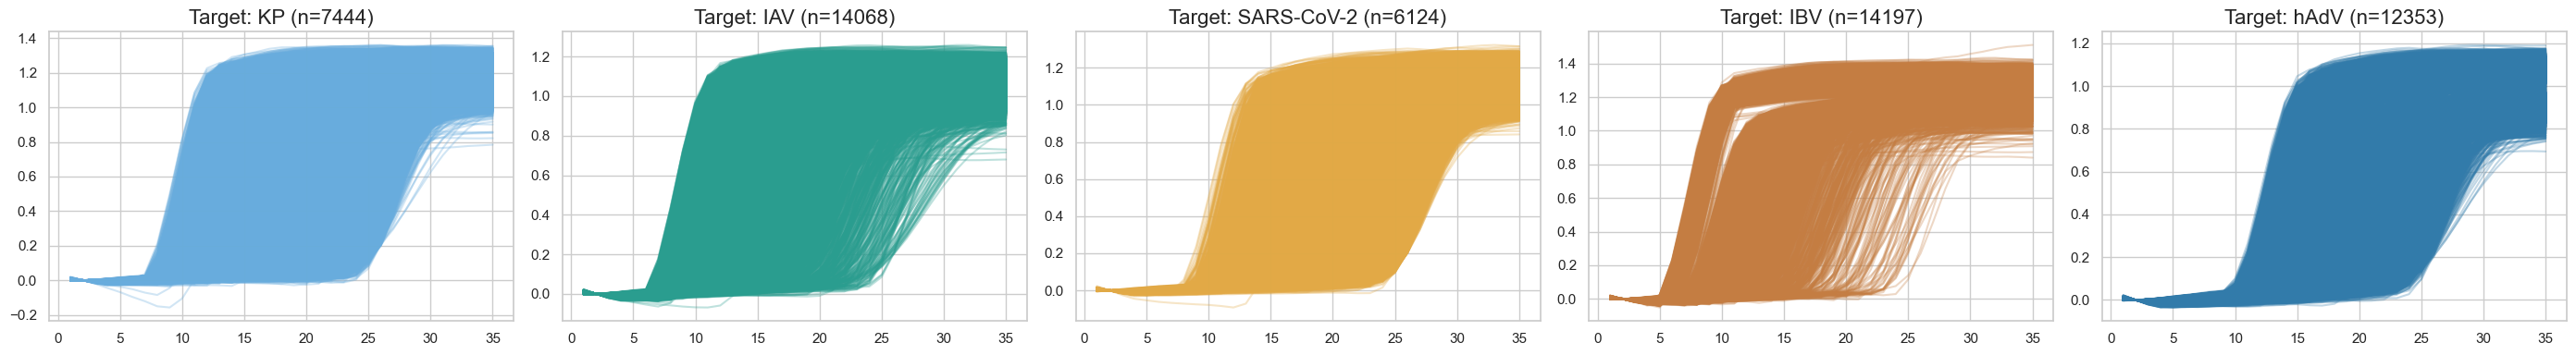

In [95]:
color_dict = {
    'hAdV': '#327BAA',
    'SARS-CoV-2': '#E2A946',
    'IAV': '#2A9D8F',
    'IBV': '#C47D42',
    'KP': '#68ACDD'
}

fig, ax = plt.subplots(1, len(set(y_dlamp)), figsize=(28, 4))
for i, y in enumerate(set(y_dlamp)):
    x_yfiltered =  X_ac_dlamp[np.where(y_dlamp == y)]
    ax[i].set_title(f"Target: {y} (n={x_yfiltered.shape[0]})", fontsize=16)
    ax[i].plot(X_time, x_yfiltered.T, c=color_dict[y], alpha=0.3)
fig.tight_layout()
plt.show()

# ACA

In [96]:
targets = ['hAdV', 'SARS-CoV-2', 'IAV', 'IBV', 'KP']
X_ac_norm_dlamp = X_ac_dlamp.copy()
for t in targets:
    mask = np.where(y_dlamp == t)
    X_ac_norm_dlamp[mask] = (X_ac_norm_dlamp[mask] - np.min(X_ac_norm_dlamp[mask])) / (np.max(X_ac_norm_dlamp[mask]) - np.min(X_ac_norm_dlamp[mask]))

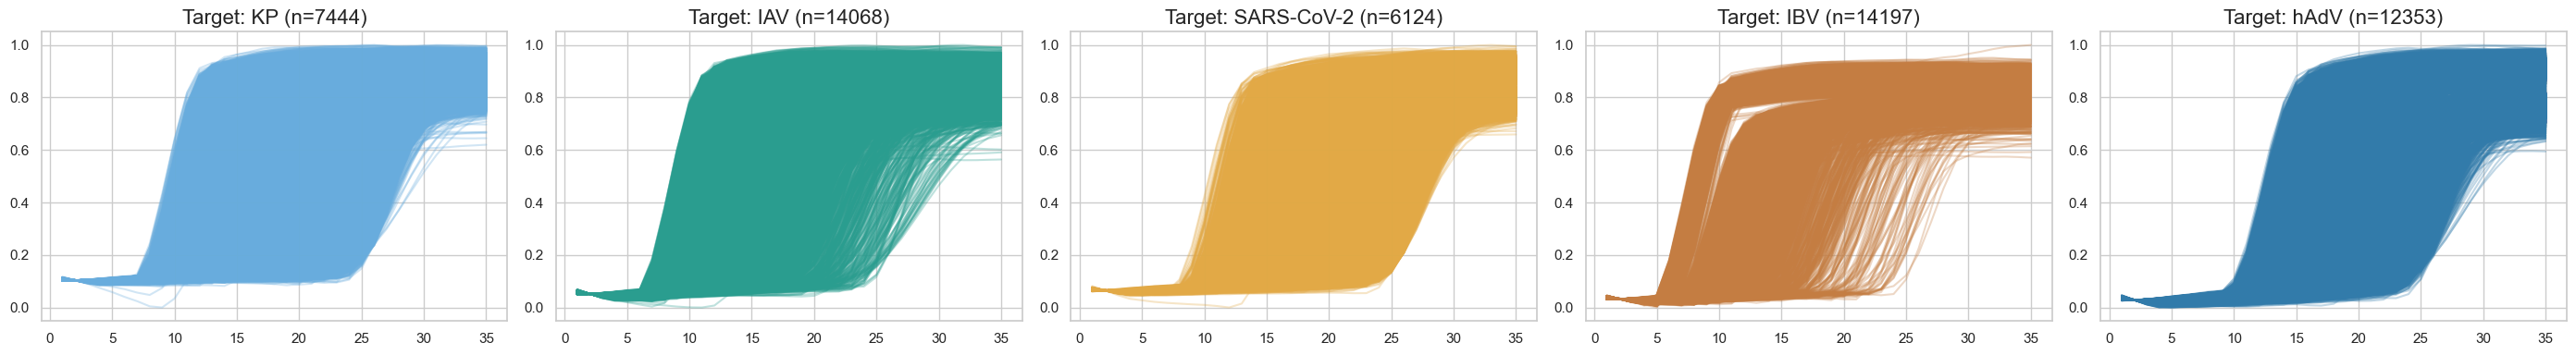

In [97]:
color_dict = {
    'hAdV': '#327BAA',
    'SARS-CoV-2': '#E2A946',
    'IAV': '#2A9D8F',
    'IBV': '#C47D42',
    'KP': '#68ACDD'
}

fig, ax = plt.subplots(1, len(set(y_dlamp)), figsize=(28, 4))
for i, y in enumerate(set(y_dlamp)):
    x_yfiltered =  X_ac_norm_dlamp[np.where(y_dlamp == y)]
    ax[i].set_title(f"Target: {y} (n={x_yfiltered.shape[0]})", fontsize=16)
    ax[i].plot(X_time, x_yfiltered.T, c=color_dict[y], alpha=0.3)
fig.tight_layout()
plt.show()

## k-NN

In [99]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold, cross_validate

knn_cls = KNeighborsClassifier(n_neighbors=10)

scoring_dict = {'accuracy': 'accuracy'}

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_validate(knn_cls, X_ac_norm_dlamp, y_dlamp, cv=skfold,
                                  scoring=scoring_dict, return_train_score=True)
        
accuracy_scores = cv_scores['test_accuracy']
print(f"Accuracy: {accuracy_scores.mean()*100:.2f}% ± {accuracy_scores.std()*100:.2f}%")

Accuracy: 97.97% ± 0.20%


In [101]:
knn_cls.fit(X_ac_norm_dlamp, y_dlamp)
print(knn_cls.score(X_ac_norm_dlamp, y_dlamp))

0.983925737275311


## UMAP

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


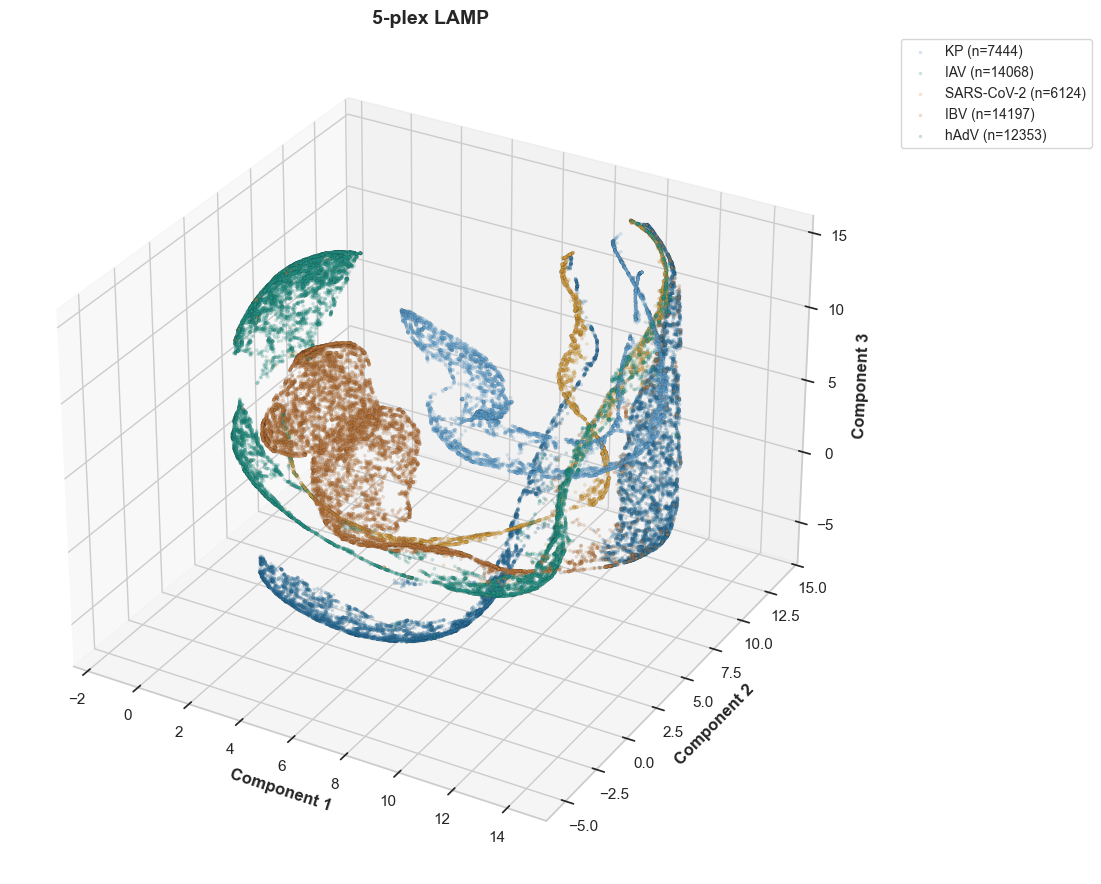

In [116]:
import umap
import tqdm as notebook_tqdm

X_ac_dlamp_umap = umap.UMAP(n_components=3, n_neighbors=15, 
                            min_dist=0.1, random_state=42).fit_transform(X_ac_norm_dlamp)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for i, y in enumerate(set(y_dlamp)):
    mask = y_dlamp == y
    ax.scatter(X_ac_dlamp_umap[mask, 0], X_ac_dlamp_umap[mask, 1], X_ac_dlamp_umap[mask, 2],
              alpha=0.5, s=5, c=color_dict[y], 
              label=f'{y} (n={np.sum(mask)})',
              edgecolors='black', linewidth=0.1)

ax.set_xlabel('Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Component 2', fontsize=12, fontweight='bold')
ax.set_zlabel('Component 3', fontsize=12, fontweight='bold')
ax.set_title('5-plex LAMP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## TSNE

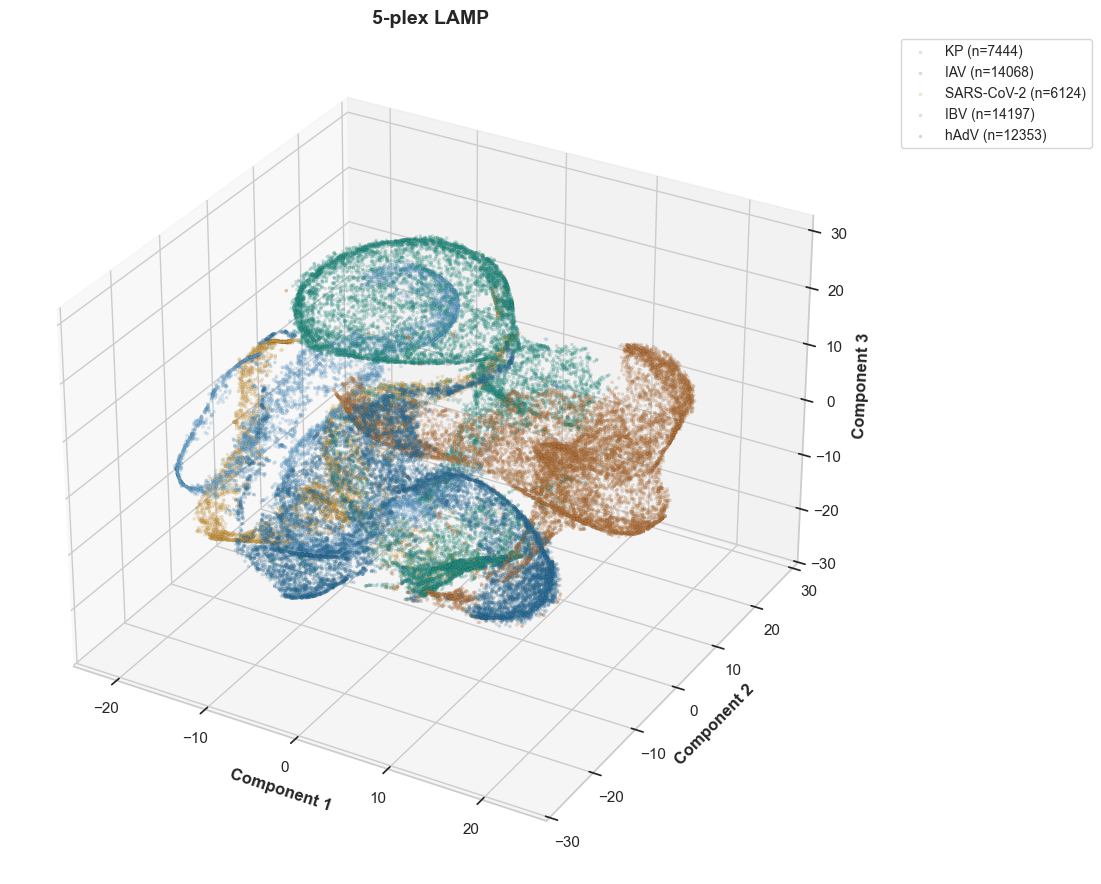

In [ ]:
from sklearn.manifold import TSNE

X_ac_dlamp_tsne = TSNE(n_components=3, init='random', learning_rate='auto', 
                   random_state=42, perplexity=100).fit_transform(X_ac_norm_dlamp)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for i, y in enumerate(set(y_dlamp)):
    mask = y_dlamp == y
    ax.scatter(X_ac_dlamp_tsne[mask, 0], X_ac_dlamp_tsne[mask, 1], X_ac_dlamp_tsne[mask, 2],
              alpha=0.5, s=5, c=color_dict[y], 
              label=f'{y} (n={np.sum(mask)})',
              edgecolors='black', linewidth=0.1)

ax.set_xlabel('Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Component 2', fontsize=12, fontweight='bold')
ax.set_zlabel('Component 3', fontsize=12, fontweight='bold')
ax.set_title('5-plex LAMP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# MCA

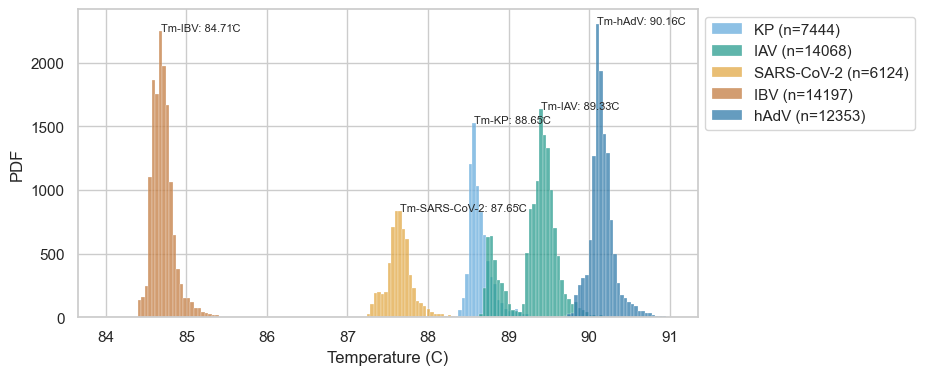

In [72]:
import math
hist_min = math.floor(X_tm_dlamp.min())
hist_max = math.ceil(X_tm_dlamp.max()) - 1
bins = (hist_max - hist_min + 1) * 20

plt.figure(figsize=(8, 4))
plt.xlabel("Temperature (C)")
plt.ylabel("PDF")
for i, y in enumerate(set(y_dlamp)):
    x_yfiltered =  X_tm_dlamp[np.where(y_dlamp == y)]
    
    counts, bins_edges, patches = plt.hist(x_yfiltered, bins=bins, range=(hist_min,hist_max), label=f"{y} (n={x_yfiltered.shape[0]})", lw=0.25, alpha=0.75, color=color_dict[y])
    
    max_index = np.argmax(counts)
    x_mid_point = (bins_edges[max_index] + bins_edges[max_index + 1]) / 2
    plt.text(x_mid_point, np.max(counts), f"Tm-{y}: {x_yfiltered.mean():.2f}۠۟C", size=8)
    
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# FFI

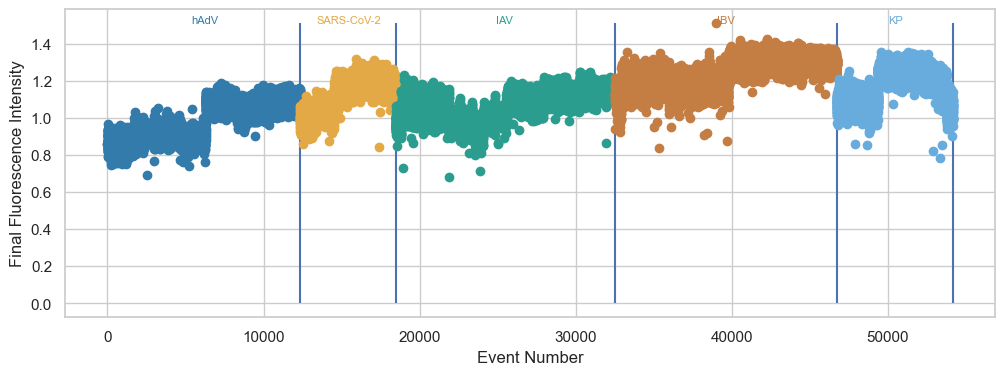

In [70]:
max_val = X_ac_dlamp[:,-1].max()
last_idx = 0
plt.figure(figsize=(12, 4))
plt.xlabel("Event Number")
plt.ylabel("Final Fluorescence Intensity")
for t in targets:
    
    x_yfiltered =  X_ac_dlamp[np.where(y_dlamp == t)][:,-1]
    y_digits = np.array(list(range(last_idx,last_idx+x_yfiltered.shape[0])))
    x_mid_point = last_idx + x_yfiltered.shape[0]/2 - len(t)*200
    last_idx += x_yfiltered.shape[0]
    plt.vlines(last_idx, 0, max_val)
    plt.plot(y_digits, x_yfiltered, 'o', c=color_dict[t], linestyle='None')
    
    plt.text(x_mid_point, max_val, t, size=8, c=color_dict[t])
    
plt.show()

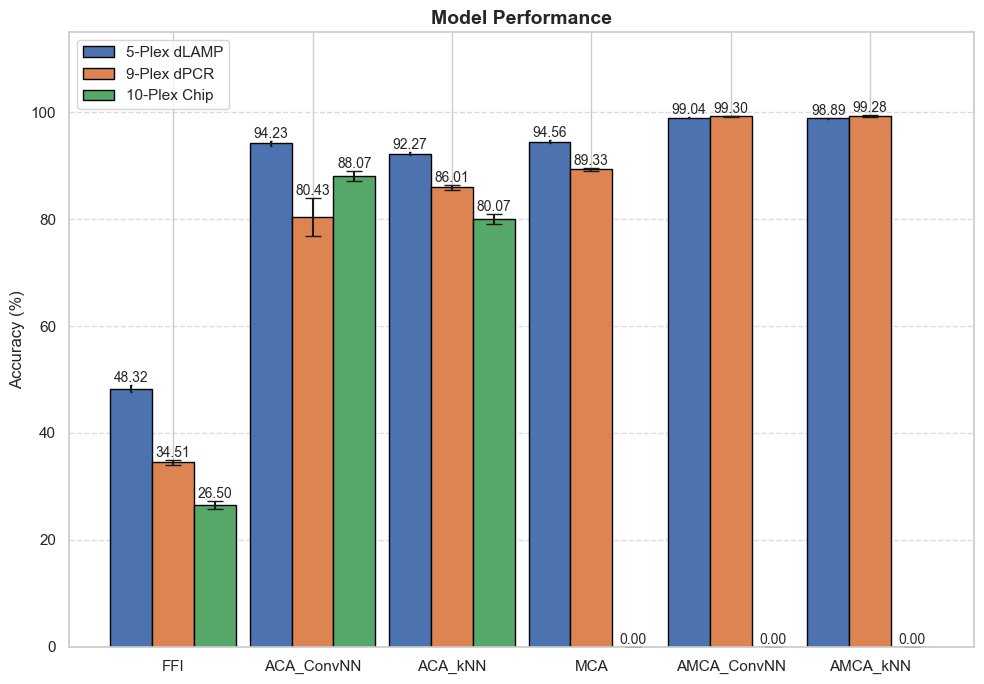

In [130]:
methods = ['FFI', 'ACA_ConvNN', 'ACA_kNN', 'MCA', 'AMCA_ConvNN', 'AMCA_kNN']
x = np.arange(len(methods))
bar_width = 0.6
fig, ax = plt.subplots(figsize=(10, 7))

dLAMP_5plex_acc_mean = [48.31873531129379, 94.23282625812914, 92.27106905681859, 94.56132330695131, 99.04218515019443, 98.88716648577517]
dLAMP_5plex_acc_std = [0.5737939391771157, 0.4288367272569513, 0.24416062940002045, 0.24515769917573677, 0.13220004556689868, 0.11790024931772496]

dLAMP_bars = ax.bar(x - bar_width/2, dLAMP_5plex_acc_mean, bar_width/2, yerr=dLAMP_5plex_acc_std, capsize=1, 
                  edgecolor='black', label='5-Plex dLAMP')

dLAMP_custom_labels = [f'{a:.2f}' for a, s in zip(dLAMP_5plex_acc_mean, dLAMP_5plex_acc_std)]
# dLAMP_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(dLAMP_5plex_acc_mean, dLAMP_5plex_acc_std)]
ax.bar_label(dLAMP_bars, labels=dLAMP_custom_labels, padding=0, fontsize=10)

dPCR_9plex_acc_mean = [34.511411224061234, 80.42600689584066, 86.01319139715045, 89.32728476419989, 99.30031653994001, 99.28154783021017]
dPCR_9plex_acc_std = [0.49999922392977203, 3.521395763921658, 0.4627713383192835, 0.3267157472697195, 0.1073976909390987, 0.15906496641217882]

dPCR_bars = ax.bar(x, dPCR_9plex_acc_mean, bar_width/2, yerr=dPCR_9plex_acc_std, capsize=6, 
                  edgecolor='black', label='9-Plex dPCR')

dPCR_custom_labels = [f'{a:.2f}' for a, s in zip(dPCR_9plex_acc_mean, dPCR_9plex_acc_std)]
# dPCR_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(dPCR_9plex_acc_mean, dPCR_9plex_acc_std)]
ax.bar_label(dPCR_bars, labels=dPCR_custom_labels, padding=0, fontsize=10)

chip_10plex_acc_mean = [26.5044664396686, 88.07187659392619, 80.06971919328382, 0, 0, 0]
chip_10plex_acc_std = [0.718598424850021, 0.9652911361936923, 0.8943081325705065, 0, 0, 0]

chip_bars = ax.bar(x + bar_width/2, chip_10plex_acc_mean, bar_width/2, yerr=chip_10plex_acc_std, capsize=6, 
                  edgecolor='black', label='10-Plex Chip')

chip_custom_labels = [f'{a:.2f}' for a, s in zip(chip_10plex_acc_mean, chip_10plex_acc_std)]
# chip_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(chip_10plex_acc_mean, chip_10plex_acc_std)]
ax.bar_label(chip_bars, labels=chip_custom_labels, padding=0, fontsize=10)

dLAMP_5plex_paper = [48.32, 0, 91.33, 94.55, 0, 98.83]
dPCR_9plex_paper = [34.5, 82.31, 0, 89.34, 99.33, 0]

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 115) 
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


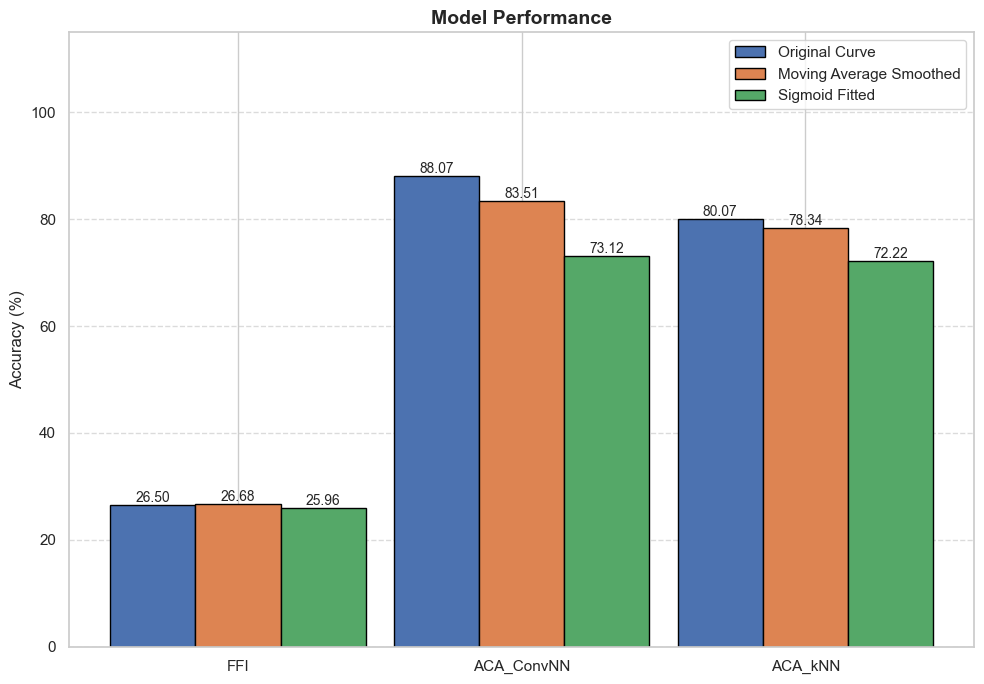

In [135]:
methods = ['FFI', 'ACA_ConvNN', 'ACA_kNN']
x = np.arange(len(methods))
bar_width = 0.6
fig, ax = plt.subplots(figsize=(10, 7))

ori_accs = [26.5044664396686, 88.07187659392619, 80.06971919328382]
sigmoid_accs =[np.float64(25.956617636922566), np.float64(73.12187590466081), np.float64(72.2171599509243)]
moving_accs = [np.float64(26.678767869205), np.float64(83.51459864076867), np.float64(78.34332308625468)]

ori_bars = ax.bar(x - bar_width/2, ori_accs, bar_width/2, capsize=1, 
                  edgecolor='black', label='Original Curve')

ori_custom_labels = [f'{a:.2f}' for a, s in zip(ori_accs, ori_accs)]
# dLAMP_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(dLAMP_5plex_acc_mean, dLAMP_5plex_acc_std)]
ax.bar_label(ori_bars, labels=ori_custom_labels, padding=0, fontsize=10)

moving_bars = ax.bar(x, moving_accs, bar_width/2, capsize=6, 
                  edgecolor='black', label='Moving Average Smoothed')

moving_custom_labels = [f'{a:.2f}' for a, s in zip(moving_accs, moving_accs)]
# chip_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(chip_10plex_acc_mean, chip_10plex_acc_std)]
ax.bar_label(moving_bars, labels=moving_custom_labels, padding=0, fontsize=10)

sigmoid_bars = ax.bar(x + bar_width/2, sigmoid_accs, bar_width/2, capsize=6, 
                  edgecolor='black', label='Sigmoid Fitted')

sigmoid_custom_labels = [f'{a:.2f}' for a, s in zip(sigmoid_accs, sigmoid_accs)]
# dPCR_custom_labels = [f'{a:.2f}±{s:.2f}' for a, s in zip(dPCR_9plex_acc_mean, dPCR_9plex_acc_std)]
ax.bar_label(sigmoid_bars, labels=sigmoid_custom_labels, padding=0, fontsize=10)




ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 115) 
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
